## Inference
Test if we can run the saved models

In [29]:
import sys
import xarray as xr
import torch
import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

sys.path.append('../src')
from Inference import sample_unet, sample_model_EDS
from Network import UNet, EDMPrecond
from DatasetUS import UpscaleDatasetDK

from torch.utils.data.dataloader import DataLoader

Set up models

In [37]:
# Subset of years
year_start = 1956
year_end = 1957

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

# Dirs
data_dir="../data/"
model_dir="Models_unet_DK"


cpu


Get checkpoints of models for both UNet and Diffusion

In [31]:
# Get models
# unet
model_unet = UNet((64, 32), 5, 3, label_dim=2, use_diffuse=False).to(device)
model_unet.load_state_dict(torch.load(f"{model_dir}/run_04.pt", map_location='cpu'))
# diffusion
# model_diff = EDMPrecond((256, 128), 8, 3).to(device)
# model_diff.load_state_dict(torch.load(f"{model_dir}/Model_chpt/diffusion.pt", map_location='cpu'))

<All keys matched successfully>

Open datasets

In [38]:
# define the datasets
datadir = "../data/"

dataset_test = UpscaleDatasetDK(datadir, year_start=year_start, year_end=year_end,
                              constant_variables=["lsm", "z"])

lat = dataset_test.lat
lon = dataset_test.lon

nlat, nlon = len(lat), len(lon)

BATCH_SIZE = 1
dataloader = DataLoader(dataset_test,
                        batch_size=BATCH_SIZE,
                        shuffle=False)


Opening files
All files accessed. Creating tensors
torch.Size([360, 3, 32, 64])
torch.Size([3])
tensor([259.5524,  -6.4844,  -7.6029]) tensor([310.5276,   7.3752,   7.3651])
Opening constant variables file (e.g. land-sea mask, topography)
Normalize z
Mean:<xarray.DataArray 'z' ()> Size: 8B
array(1049.68169797), Std<xarray.DataArray 'z' ()> Size: 8B
array(2159.41336176)
Dataset initialized.


 Sample our batch of 1 for both models

In [39]:
t = 0   # time index
test_batch = next(iter(dataloader))

# Run models
coarse, fine, predicted_unet = sample_unet(test_batch, model_unet, 
                                           device, dataset_test)
# _, _, predicted_diff = sample_model_EDS(test_batch, model_diff, 
#                                        device, dataset_test, num_steps=40)

coarse = coarse.detach().numpy()
fine = fine.detach().numpy()
predicted_unet = predicted_unet.detach().numpy()
# predicted_diff = predicted_diff.detach().numpy()


In [40]:
print(coarse.shape, fine.shape, predicted_unet.shape) #, predicted_diff.shape)

# Extract temporal information
year = test_batch["year"].item() # year
doy = test_batch["doy"].item()  # day of year
hour = test_batch["hour"].item()  # hour

# Convert to a readable date
from datetime import datetime, timedelta
year = year * 100 + 1940
doy = doy * 360
hour = hour * 24
date = datetime(round(year), 1, 1) + timedelta(days=round(doy), hours=round(hour))
date_str = date.strftime("%Y-%m-%d %H:%M")

print(date_str)

(1, 3, 32, 64) (1, 3, 32, 64) (1, 3, 32, 64)
1956-01-21 01:00


## Plot
Plot all three variables for this one timestep

In [43]:
# Variables - defines three separate subplots
varnames = ["VAR_2T", "VAR_10U", "VAR_10V"]
# vmin = [250, -10, -10]
# vmax = [300, 10, 10]
vmin = [273.15-20, -20, -20]
vmax = [273.15+20, 20, 20]
# vmax_stds = [3, 1, 1]
cmaps = ["coolwarm", "BrBG_r", "BrBG_r"]

plot_varnames = ["Temperature", "Zonal wind", "Meridional wind"]
plot_var_labels = ["K", "m/s", "m/s"]
plt.rcParams.update({'font.size': 18})

<Figure size 640x480 with 0 Axes>

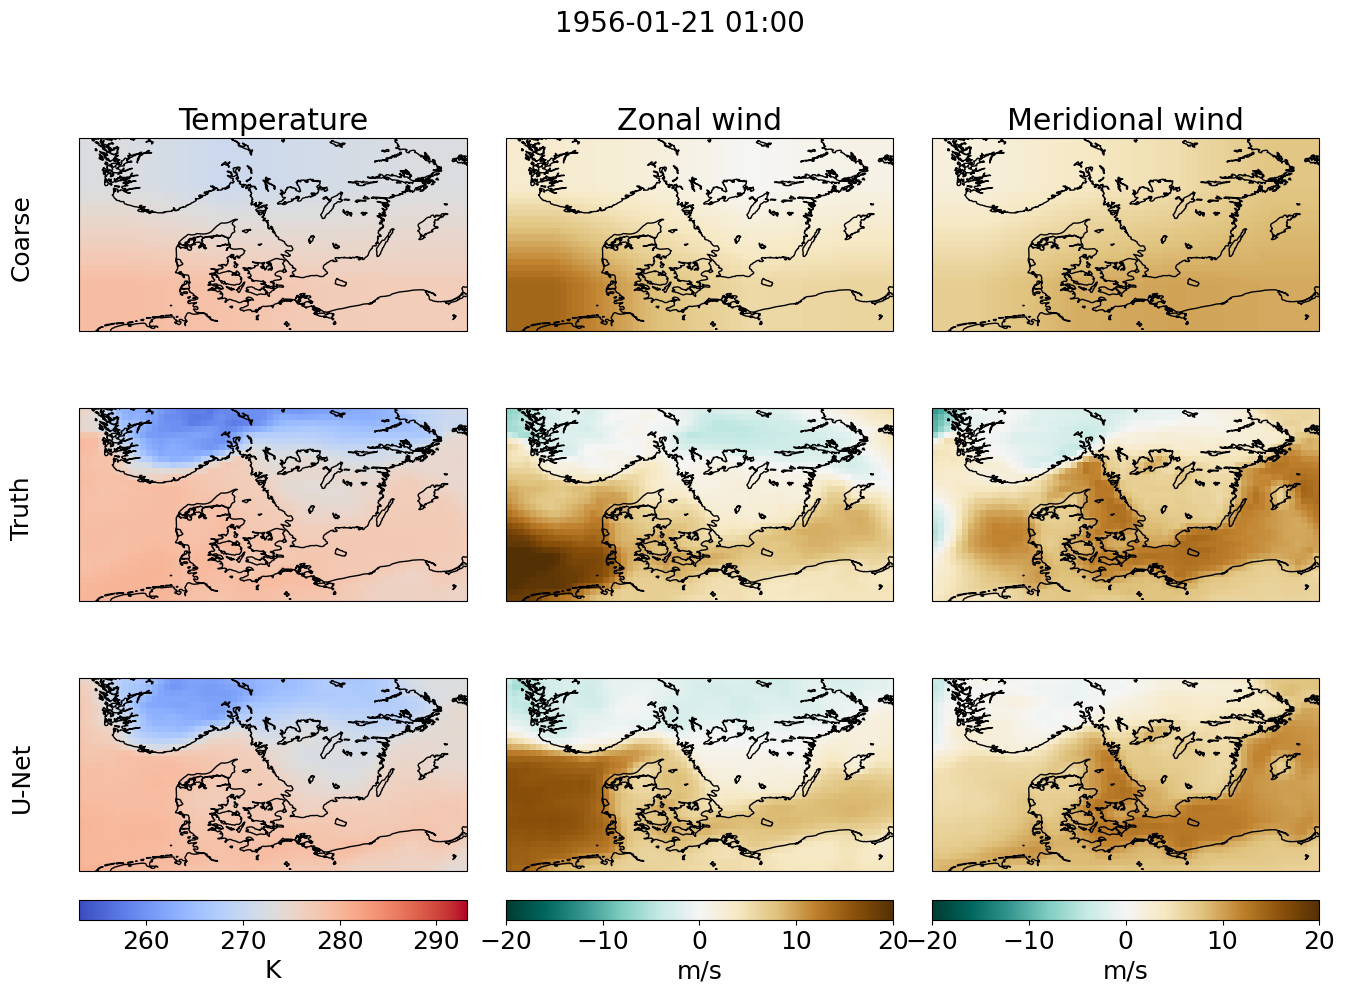

In [44]:
plt.clf()
# fig, axs = plt.subplots(4,3, figsize=(16, 10.2),
#                         subplot_kw={'projection': ccrs.PlateCarree()},
#                         gridspec_kw={'wspace': 0.1,
#                                      'hspace': 0.1})
fig, axs = plt.subplots(3,3, figsize=(16, 10.2),
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        gridspec_kw={'wspace': 0.1,
                                     'hspace': 0.1})

for i, varname in enumerate(varnames):

    # Plot truth for first plot
    ax = axs[0, i]
    plt.sca(ax)
    ax.coastlines()
    ax.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none')
    pcm = plt.pcolormesh(lon, lat, coarse[0, i],
                   vmin=vmin[i], vmax=vmax[i],
                   shading='nearest',
                   cmap=cmaps[i])
    plt.title(f"{plot_varnames[i]}")
    if i == 0:
        plt.text(lon[0]-2, lat[len(lat) // 2], f"Coarse", transform=ccrs.PlateCarree(),
                 rotation='vertical', ha='right', va='center', zorder=10)

    ax = axs[1, i]
    plt.sca(ax)
    ax.coastlines()
    ax.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none')
    pcm = plt.pcolormesh(lon, lat, fine[0, i],
                   vmin=vmin[i], vmax=vmax[i],
                   shading='nearest',
                   cmap=cmaps[i])
    if i == 0:
        plt.text(lon[0]-2, lat[len(lat) // 2], f"Truth", transform=ccrs.PlateCarree(),
                 rotation='vertical', ha='right', va='center', zorder=10)

    ax = axs[2, i]
    plt.sca(ax)
    ax.coastlines()
    ax.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none')
    pcm = plt.pcolormesh(lon, lat, predicted_unet[0, i],
                   vmin=vmin[i], vmax=vmax[i],
                   shading='nearest',
                   cmap=cmaps[i])
    if i == 0:
        plt.text(lon[0]-2, lat[len(lat) // 2], f"U-Net", transform=ccrs.PlateCarree(),
                 rotation='vertical', ha='right', va='center', zorder=10)

    # ax = axs[3, i]
    # plt.sca(ax)
    # ax.coastlines()
    # ax.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none')
    # pcm = plt.pcolormesh(lon, lat, predicted_diff[0, i],
    #                vmin=vmin[i], vmax=vmax[i],
    #                shading='nearest',
    #                cmap=cmaps[i])
    # if i == 0:
    #     plt.text(lon[0]-2, lat[len(lat) // 2], f"Diffusion", transform=ccrs.PlateCarree(),
    #              rotation='vertical', ha='right', va='center', zorder=10)
    # cax = axs[3, i].inset_axes([0., -0.25, 1, 0.1])
    
    cax = axs[2, i].inset_axes([0., -0.25, 1, 0.1])
    plt.colorbar(pcm, cax = cax, orientation="horizontal", label=f"{plot_var_labels[i]}")

fig.suptitle(f"{date_str}", fontsize=20, y=0.98)
plt.show()